# Fast Adaptation of Physics-Informed Hybrid Thermodynamic Model in Pneumatic Artifical Muscles

The aim of this script is to study the capacity of fast adaptation with physics-informed hybrid model that we developed in previous research named "**Learning an inverse thermodynamic model for Pneumatic Artificial Muscles control**". This study can be divided into 3 step. In step 1, we recap the modelling of thermodynamic behaviour of a small PAM, meaning by the previously proposed approach. Then in step 2, we reapply the same approach with the data from a bigger muscle. The comparaison of these two types of muscle can be found in the figure below. The diameter of the bigger muscle is twice the diameter of the small muscle which makes the volume of big muscle $V_{bm}$ is about four time of the volume of small muscle $V_{sm}$. Based on this assumption, in step 3, we add a constant adaptation matrix $Q = [4]$ after the final layer of the NN part in the hybrid model of small muscle $\hat q_{sm} = f_{sm}(\varepsilon, \dot \varepsilon, P, \dot P; \theta^*_{sm})$. By reusing the parameters $\theta_{sm}$ from $f_{sm}$, we want to investigate if the fine-tuning process of $\theta^*_{sm}$ on the same $\cal{D}_{bm}$ is faster and more accurate than the process in step 2 or not.

# 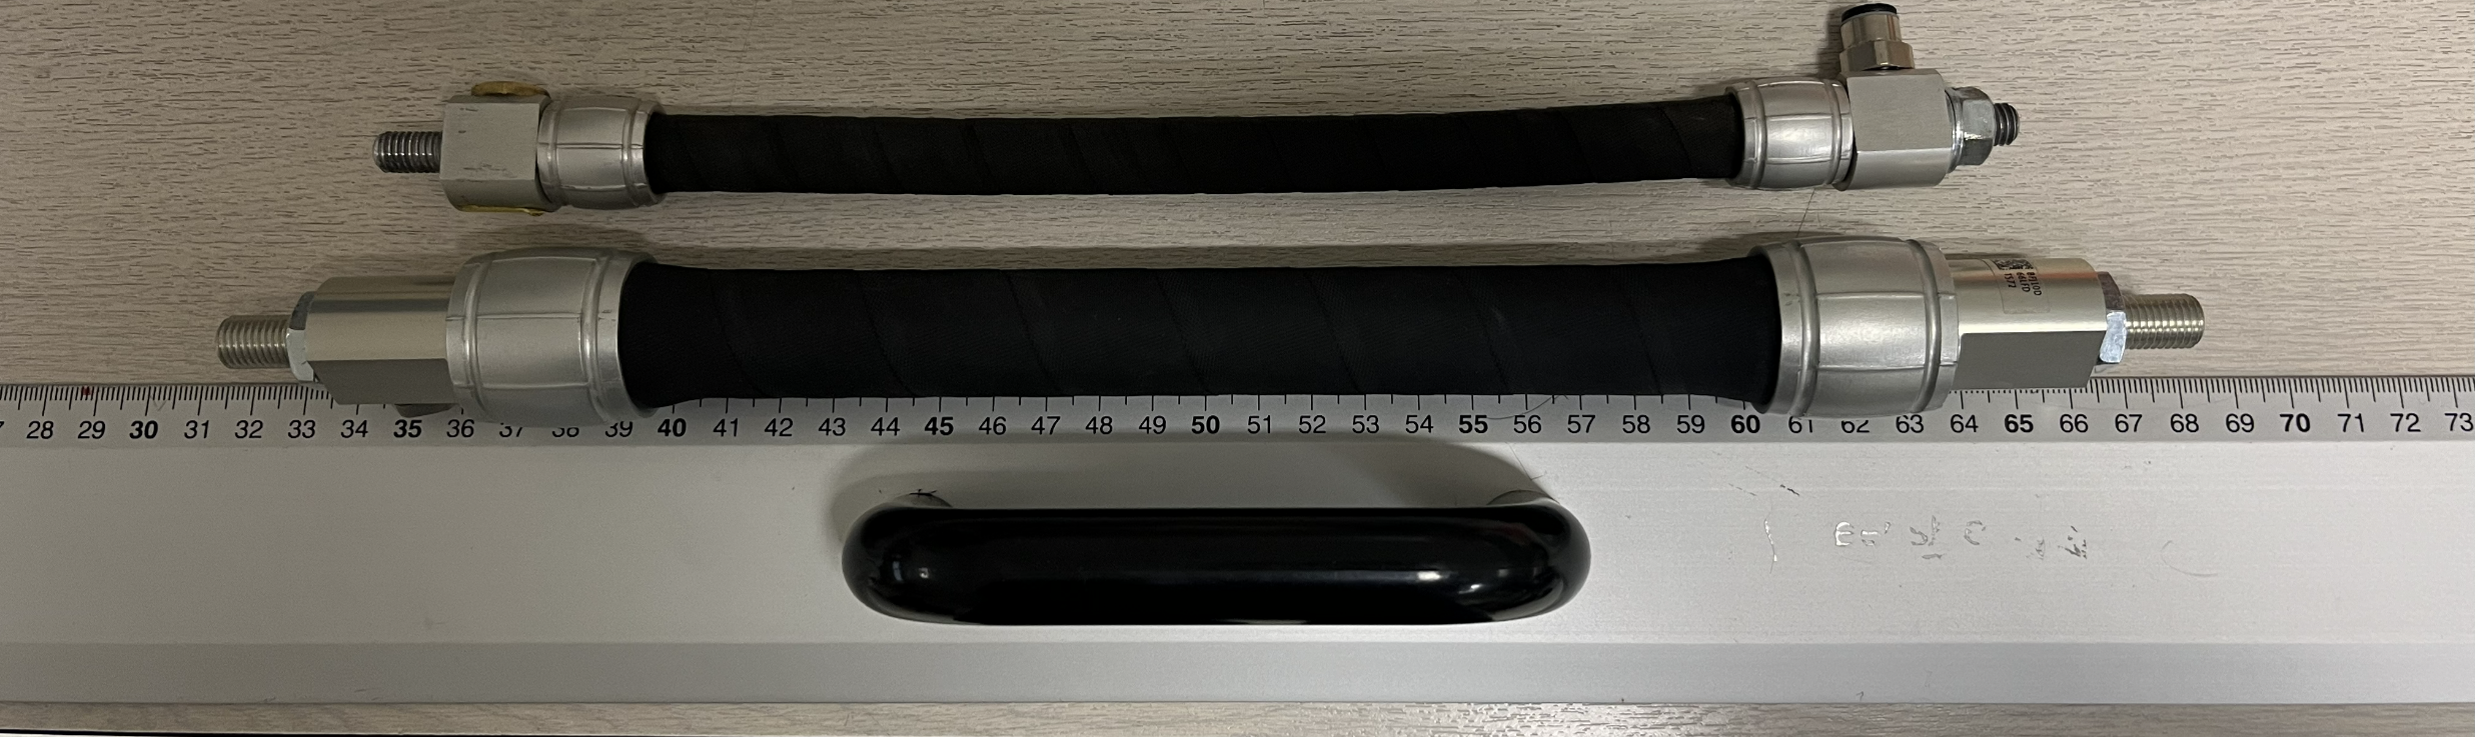

First we import the neccesary modules including the self-defined utils

In [ ]:
import torch
from torch import nn as nn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
from mpl_toolkits.mplot3d import axes3d
import scipy.io
from torch.utils.data import DataLoader, random_split, TensorDataset
import pandas as pd
import time

from utils import GiveMeDataMuscleAbove, GiveMeDataMuscleBelow, CreateTensorLoader, plotplot, train_loop, test_loop, plotLossEpoch, plotSemilogyLossEpoch, train_loop_FA, test_loop_FA, save_checkpoint
%matplotlib inline
%matplotlib widget

In [ ]:
torch.manual_seed(66)
torch.cuda.manual_seed(66)
torch.backends.cudnn.deterministic = True
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.net=nn.Sequential(
            nn.Linear(4,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,1,dtype=torch.float32),
            )
    def forward(self, x):
        return self.net(x)
    
class Net_2(nn.Module):
    def __init__(self):
        super(Net_2, self).__init__()
        self.net=nn.Sequential(
            nn.Linear(4,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,128,dtype=torch.float32),
            nn.Softplus(),
            nn.Linear(128,1,dtype=torch.float32),
            nn.Linear(1,1,dtype=torch.float32),
            )
    def forward(self, x):
        return self.net(x)

## Step 1 Training a Thermodynamic Model in $\cal{D}_{sm}$
The data used is a combination of sinusoidal signals of different amplitude and frequencies.

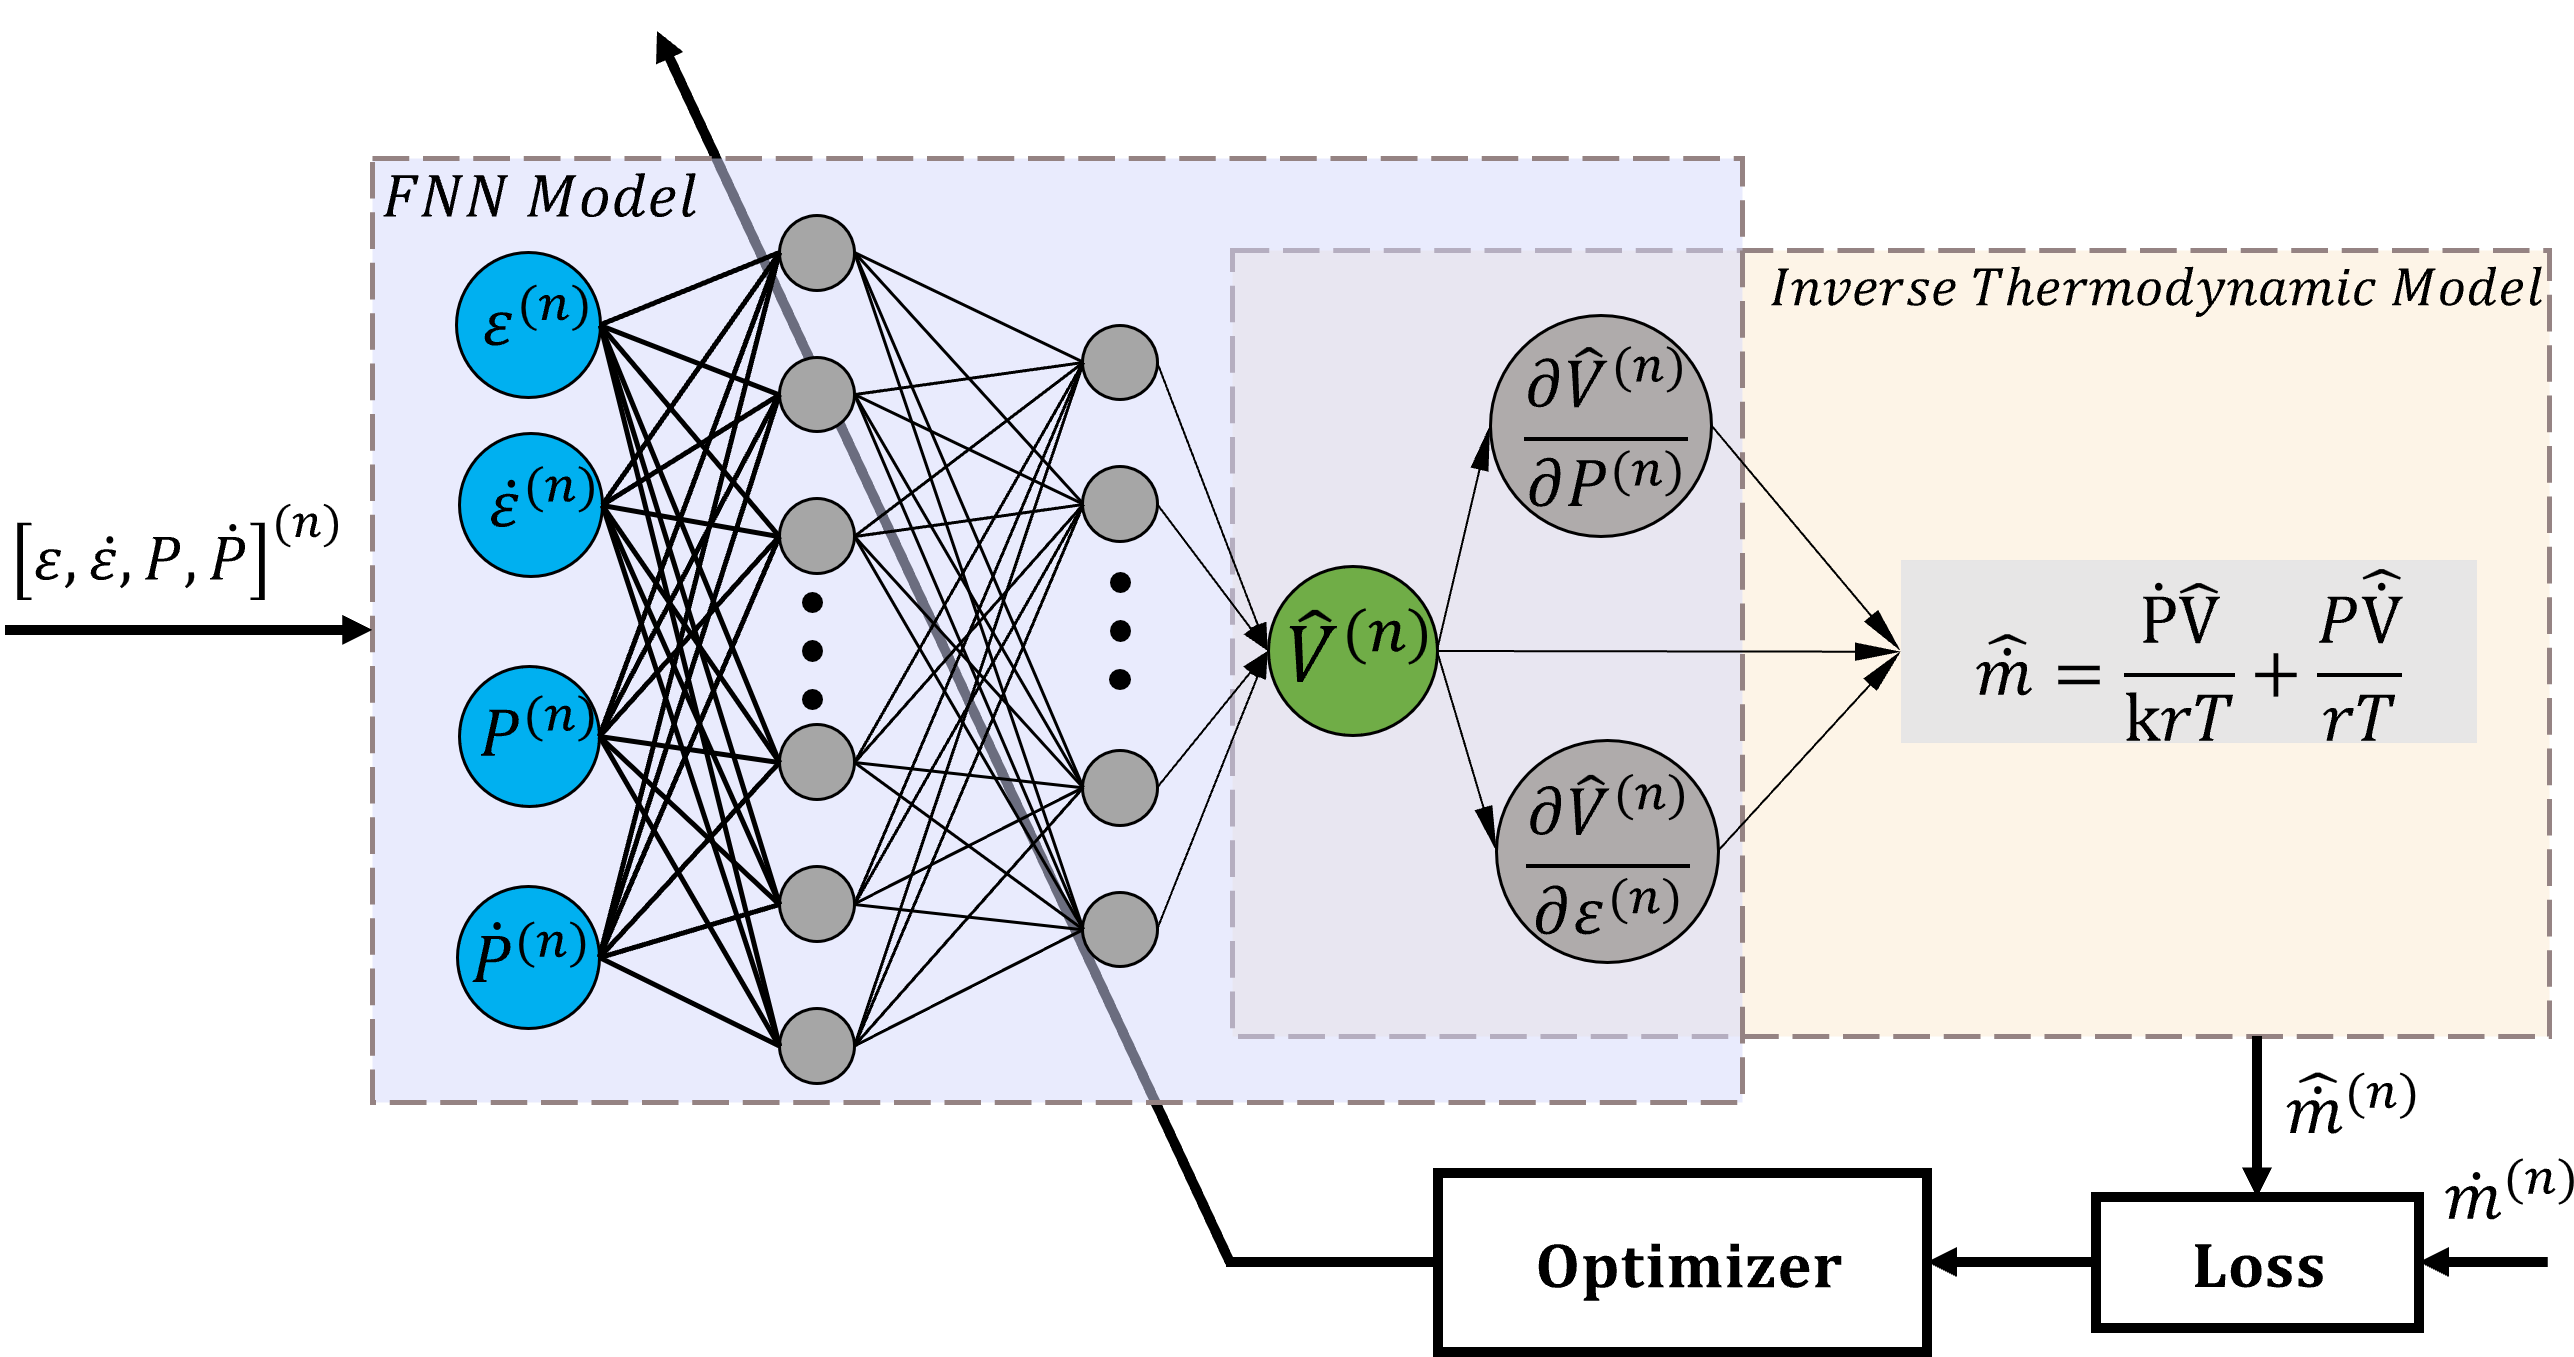{ width=50% }

In [ ]:
file_path = r"C:\\Users\\gwang\\OneDrive - INSA Lyon\\code Python\\FastAdaptation\\code\\data_sm\\sinus_smallmuscle_0g.mat"
# Load the .mat file
mat = scipy.io.loadmat(file_path)
data_train = mat['data']
e_h, deh_dt, P_h, dPdt_h, q_h = GiveMeDataMuscleAbove(data_train)

train_ratio = .8
batch_size = 1024
seed = 66
gpu = 1
train_loader, test_loader = CreateTensorLoader(e_h, deh_dt, P_h, dPdt_h, q_h, 10, train_ratio, batch_size, seed, gpu)
# plotplot(data_train)

In [ ]:
net_sm = Net()
net_sm.to('cuda') if gpu else net_sm.to('cpu')

In [ ]:
loss_function = nn.MSELoss()
optim_sm = torch.optim.Adam(Net.parameters(net_sm), lr=1e-4, weight_decay=1e-5)

In [ ]:
Loss_train_sm = []
Loss_test_sm =[]

In [ ]:
print("Model and data is currently on:", next(net_sm.parameters()).device)
print(f"Optimizer = {type(optim_sm).__name__}\nLoss Function = {type(loss_function).__name__}")

target_loss=.001
start_time = time.time()
for t in range(10000):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_loader, net_sm, loss_function, optim_sm, Loss_train_sm, batch_size)
    test_loss = test_loop(test_loader, net_sm, loss_function)
    Loss_test_sm.append(test_loss)
    if t % 10 == 0:
        torch.save(net_sm.state_dict(), f"net_sm.pth")
        
    if test_loss <= target_loss and train_loss <= target_loss:
        print(test_loss)
        break

end_time = time.time()
execution_time = end_time - start_time
execution_time

$\cal{D}_{sm} \sim Normal(\mu = 0.211, \sigma^2 = 59.719)$

**Coefficient of determination**, usually called $R^2$ (R-squared), is a statistical metric that measures how well a model explains the variance in the data.

$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$

residual sum of squares (model error) : $SS_{res} = \Sigma_i(y_i - \hat y_i)^2$

total sum of squares (total data variance) : $SS_{tot} = \Sigma_i(y_i - \bar y_i)^2$

$R^2 = 1 - \frac{MSE}{Var(\dot m)} = 97.82 \%$

In [ ]:
plotLossEpoch(Loss_train_sm, Loss_test_sm, 1, 'loss_sm.svg')
plotSemilogyLossEpoch(Loss_train_sm, Loss_test_sm, 1, 'semilogy_loss_sm.svg')

In [ ]:

np.save(f"loss_sm_train.npy", Loss_train_sm)
np.save(f"loss_sm_test.npy", Loss_test_sm)

## Step 2 Training a Thermodynamic Model in $\cal{D}_{bm}$
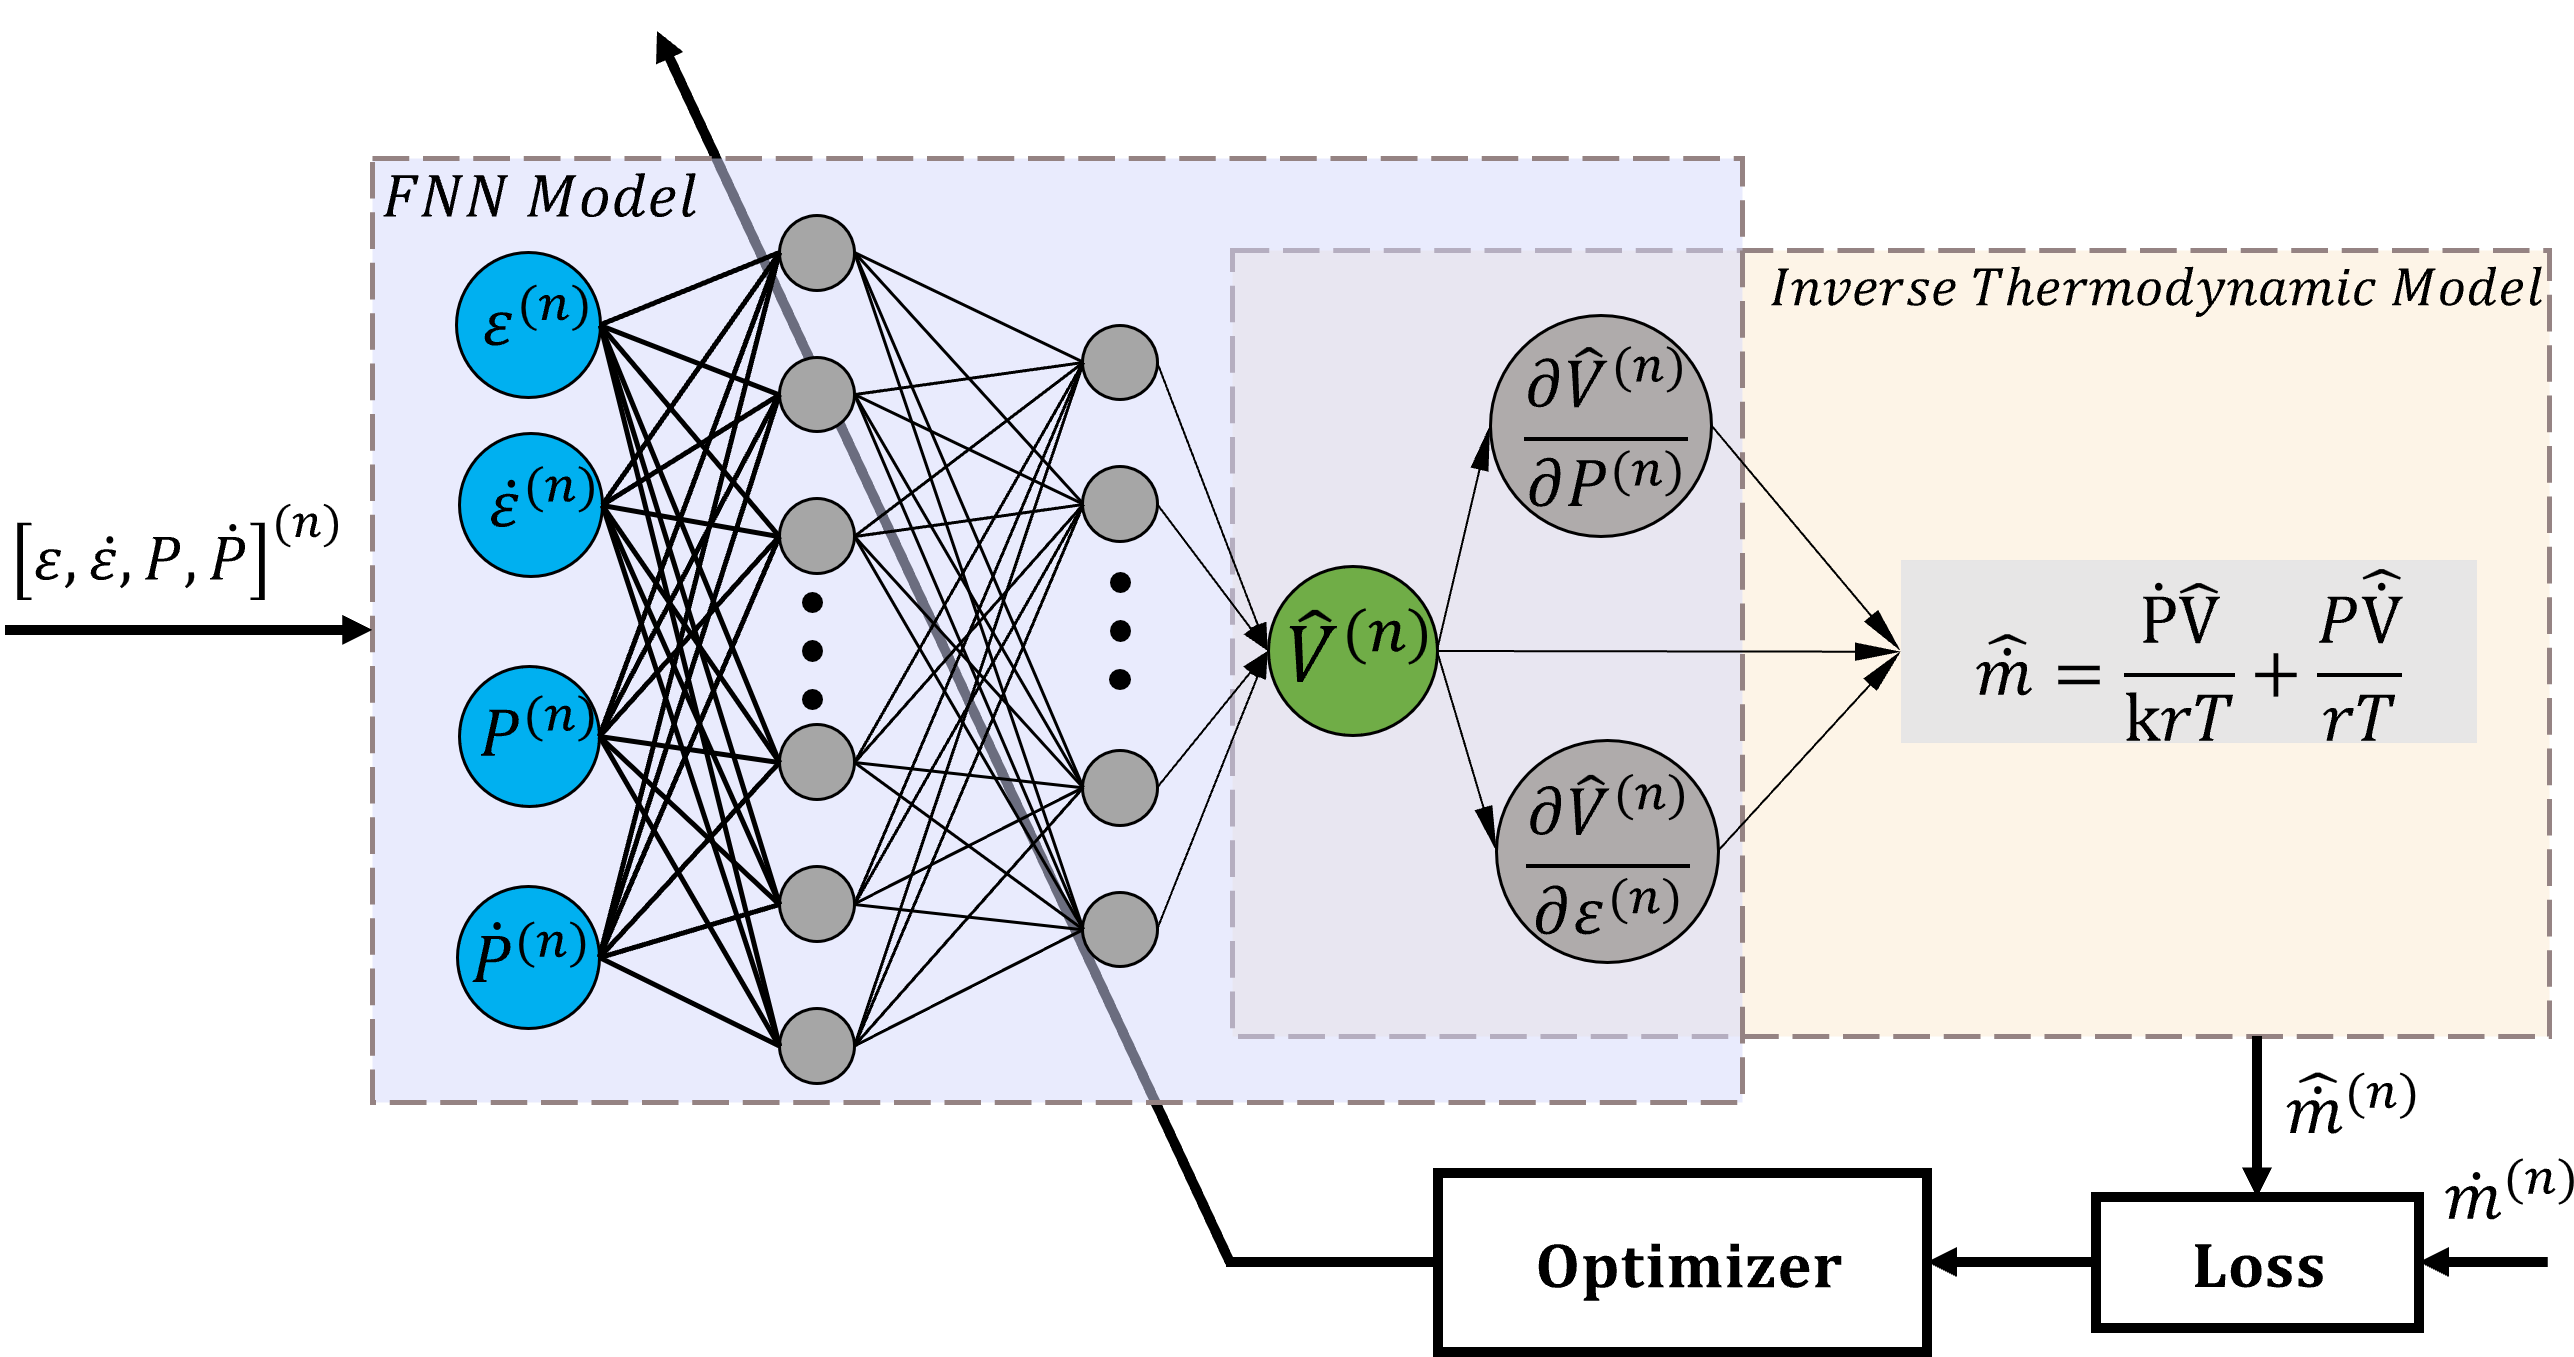{ width=50% }

In [ ]:
file_path = r"C:\\Users\\gwang\\OneDrive - INSA Lyon\\code Python\\FastAdaptation\\code\\data_bm\\sinus_bigmuscle_0g.mat"
# Load the .mat file
mat = scipy.io.loadmat(file_path)
data_train = mat['data']

train_ratio = .8
batch_size = 1024
seed = 66
gpu = 0
e_h, deh_dt, P_h, dPdt_h, q_h = GiveMeDataMuscleAbove(data_train)
train_loader, test_loader = CreateTensorLoader(e_h, deh_dt, P_h, dPdt_h, q_h, 100, train_ratio, batch_size, seed, gpu)
# plotplot(data_train)

In [ ]:
net_bm = Net()
net_bm.to('cuda') if gpu else net_bm.to('cpu')

In [ ]:
optim_bm = torch.optim.Adam(Net.parameters(net_bm), lr=1e-4, weight_decay=1e-5)

In [ ]:
Loss_train_bm = []
Loss_test_bm =[]

In [ ]:
print("Model and data is currently on:", next(net_bm.parameters()).device)
print(f"Optimizer = {type(optim_bm).__name__}\nLoss Function = {type(loss_function).__name__}")

target_loss=.001
start_time = time.time()
for t in range(10):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_loader, net_bm, loss_function, optim_bm, Loss_train_bm, batch_size)
    test_loss = test_loop(test_loader, net_bm, loss_function)
    Loss_test_bm.append(test_loss)
    if test_loss <= target_loss and train_loss <= target_loss:
        print(test_loss)
        break

end_time = time.time()
execution_time = end_time - start_time

$\cal{D}_{bm} \sim Normal(\mu = 0.318, \sigma^2 = 263.37)$

**Coefficient of determination**, usually called $R^2$ (R-squared), is a statistical metric that measures how well a model explains the variance in the data.

$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$

residual sum of squares (model error) : $SS_{res} = \Sigma_i(y_i - \hat y_i)^2$

total sum of squares (total data variance) : $SS_{tot} = \Sigma_i(y_i - \bar y_i)^2$

$R^2 = 1 - \frac{MSE}{Var(\dot m)} = 97.95 \%$

In [ ]:
plotLossEpoch(Loss_train_bm, Loss_test_bm, 1, 'loss_bm.svg')
plotSemilogyLossEpoch(Loss_train_bm, Loss_test_bm, 1, 'semilogy_loss_bm.svg')

In [ ]:
torch.save(net_bm.state_dict(), f"net_bm.pth")
np.save(f"loss_bm_train.npy", Loss_train_bm)
np.save(f"loss_bm_test.npy", Loss_test_bm)

## Step 3 Fast Adaptation of $net_{sm}$ by fine-tuning in $\cal{D}_{bm}$
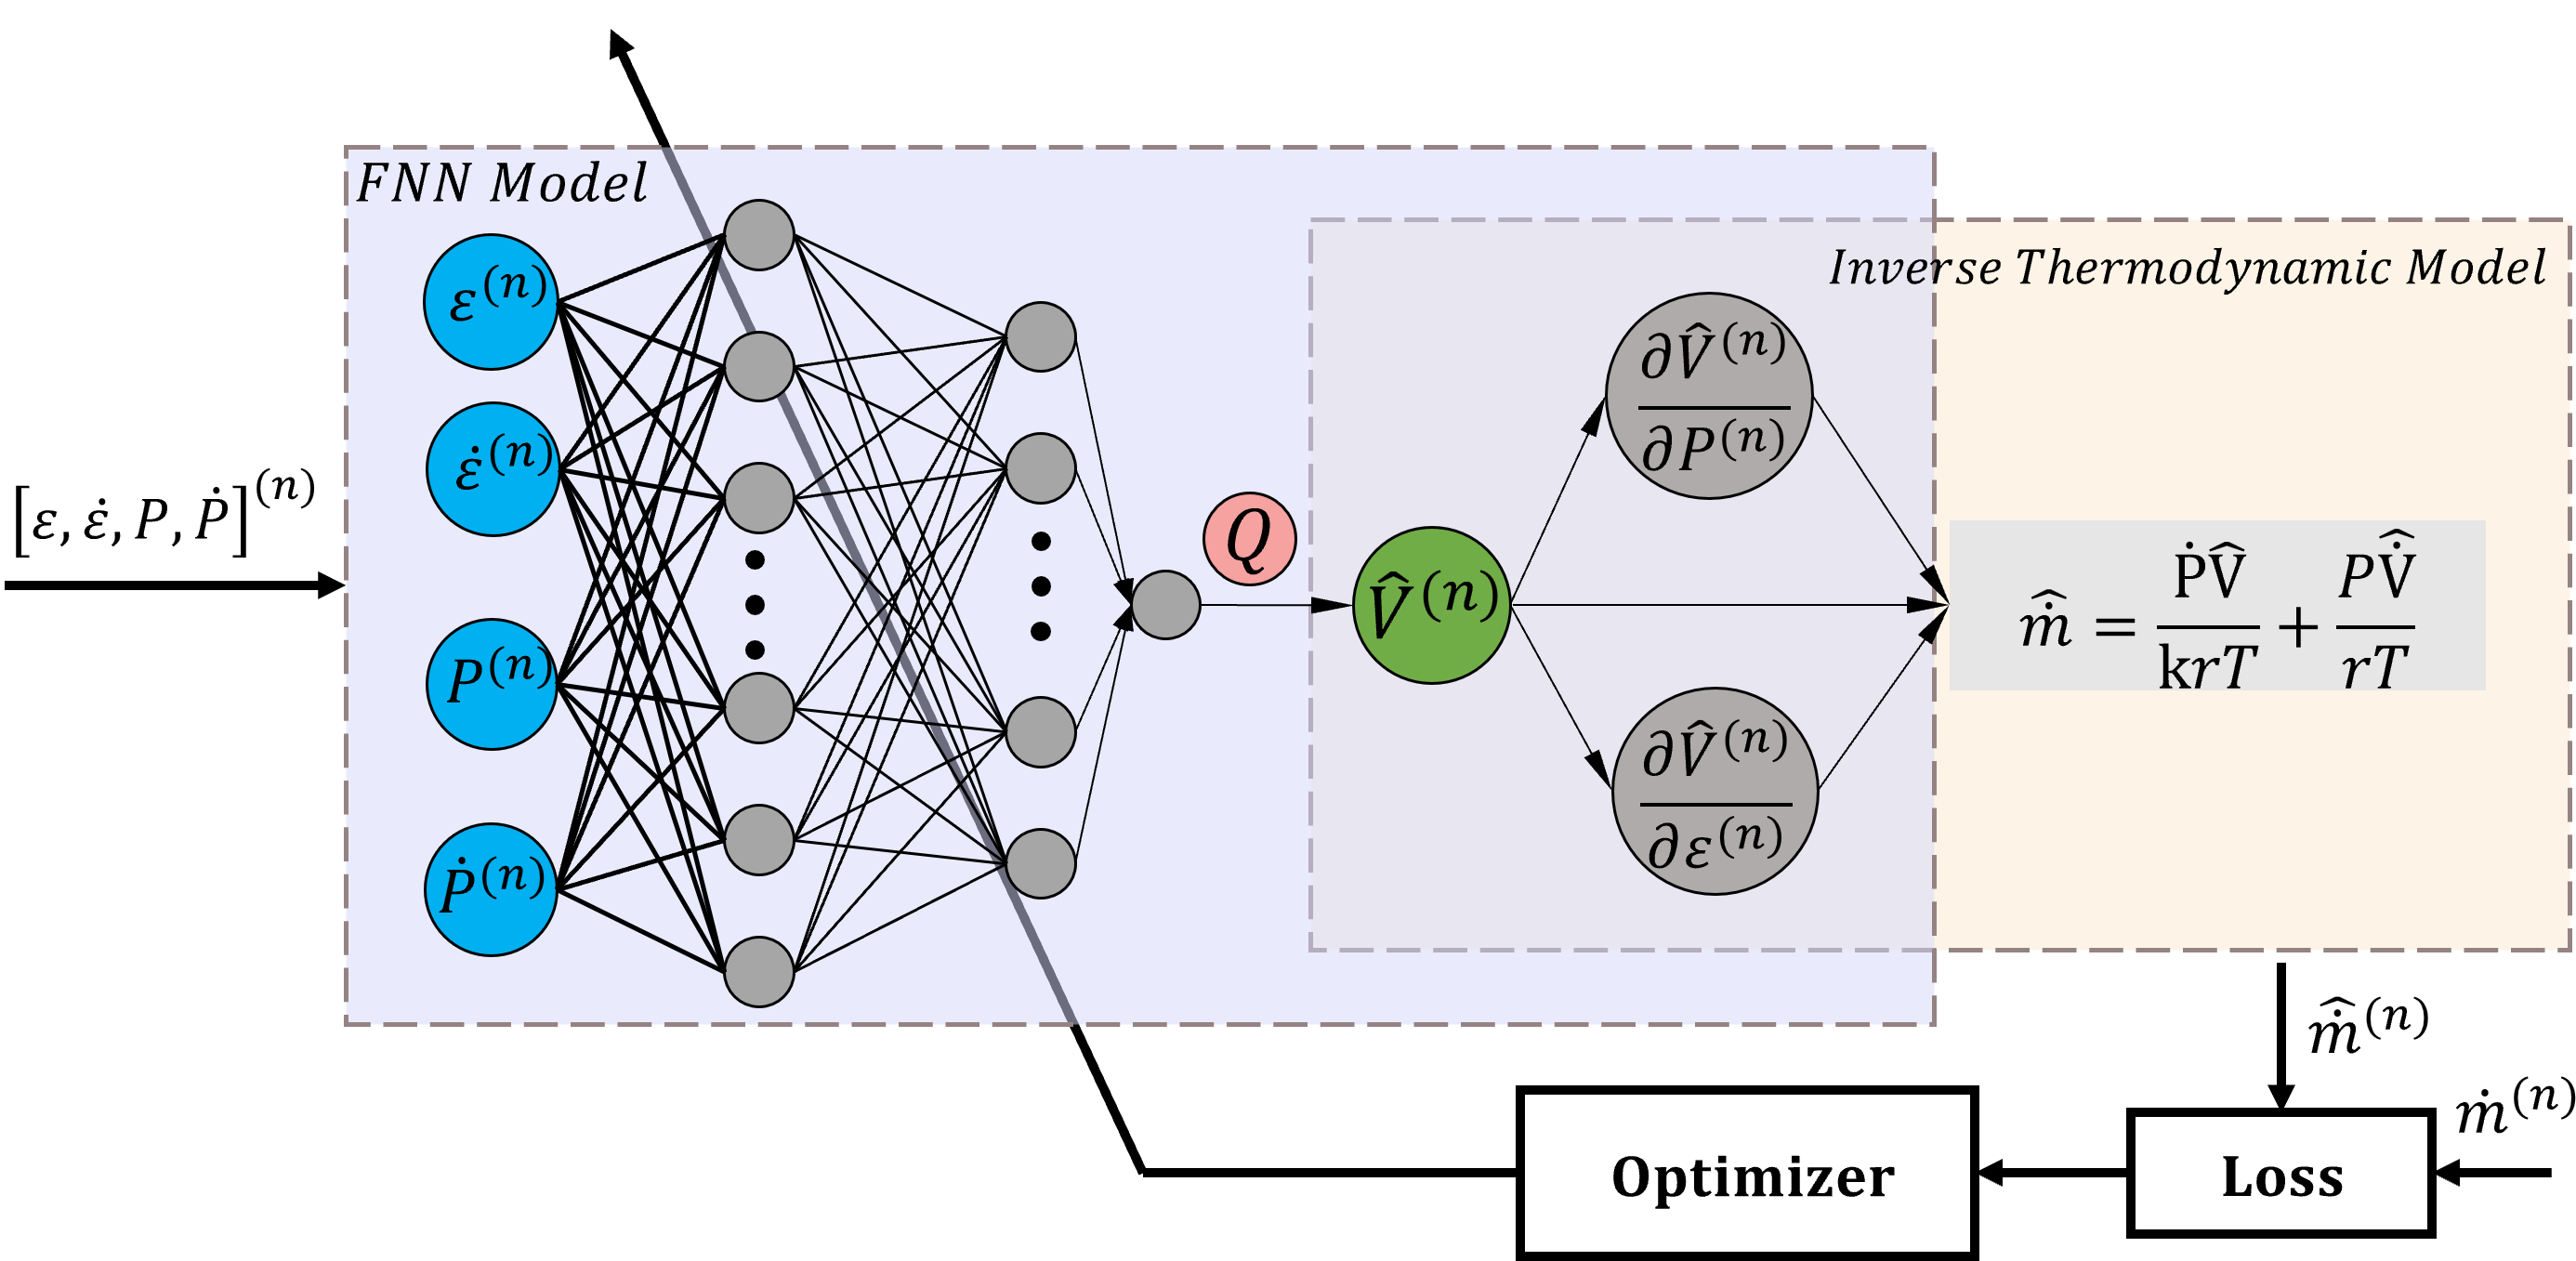{ width=50% }

In [ ]:
net_FA = Net()
net_FA.load_state_dict(torch.load('net_sm.pth'))
net_FA.train()
net_FA.to('cuda') if gpu else net_FA.to('cpu')

optim_FA = torch.optim.Adam(Net.parameters(net_FA), lr=1e-4, weight_decay=1e-5)

Loss_train_FA = []
Loss_test_FA =[]

In [ ]:
print("Model and data is currently on:", next(net_FA.parameters()).device)
print(f"Optimizer = {type(optim_FA).__name__}\nLoss Function = {type(loss_function).__name__}")

target_loss=.001
start_time = time.time()
for t in range(1000):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_loader, net_FA, loss_function, optim_FA, Loss_train_FA, batch_size)
    test_loss = test_loop(test_loader, net_FA, loss_function)
    Loss_test_FA.append(test_loss)
    if test_loss <= target_loss and train_loss <= target_loss:
        print(test_loss)
        break

end_time = time.time()
execution_time = end_time - start_time

In [ ]:
plotLossEpoch(Loss_train_FA, Loss_test_FA, 0, 'loss_FA.svg')
plotSemilogyLossEpoch(Loss_train_FA, Loss_test_FA, 0, 'semilogy_loss_FA.svg')

# Step 3.5 Update the $Q$ aswell during the fine-tuning

In [ ]:
net_FA_2 = Net_2()
sm_state = torch.load('net_sm.pth')
net_FA_2_state = net_FA_2.state_dict()

for name, param in sm_state.items():
    if name in net_FA_2_state and net_FA_2_state[name].size() == param.size():
        net_FA_2_state[name] = param
        print(f"Loaded {name}")
    else:
        print(f"Skipped {name}")

net_FA_2.load_state_dict(net_FA_2_state)

with torch.no_grad():
    net_FA_2.net[5].weight.fill_(4.0)
    net_FA_2.net[5].bias.fill_(0.0)
    
net_FA_2.train()
net_FA_2.to('cuda') if gpu else net_FA.to('cpu')

lr = 1e-4
optim_FA_2 = torch.optim.Adam([
    {'params': net_FA_2.net[0].parameters(), 'lr': lr},
    {'params': net_FA_2.net[2].parameters(), 'lr': lr},
    {'params': net_FA_2.net[4].parameters(), 'lr': lr},
    {'params': net_FA_2.net[5].parameters(), 'lr': lr* 0.2 },
], weight_decay=1e-5) #* 0.2

In [ ]:
Loss_train_FA_2 = []
Loss_test_FA_2 =[]

print("Model and data is currently on:", next(net_FA_2.parameters()).device)
print(f"Optimizer = {type(optim_FA_2).__name__}\nLoss Function = {type(loss_function).__name__}")

target_loss=.001
start_time = time.time()
for t in range(1000):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loss = train_loop(train_loader, net_FA_2, loss_function, optim_FA_2, Loss_train_FA_2, batch_size)
    test_loss = test_loop(test_loader, net_FA_2, loss_function)
    Loss_test_FA_2.append(test_loss)
    if test_loss <= target_loss and train_loss <= target_loss:
        print(test_loss)
        break

end_time = time.time()
execution_time = end_time - start_time

In [ ]:
plotLossEpoch(Loss_train_FA_2, Loss_test_FA_2, 0, 'loss_FA.svg')
plotSemilogyLossEpoch(Loss_train_FA_2, Loss_test_FA_2, 0, 'semilogy_loss_FA.svg')

In [ ]:
net_FA_2.state_dict()

In [ ]:
for batch, (e, dedt, P, dPdt, y) in enumerate(train_loader):
    X = torch.column_stack((e*10, dedt*10, P, dPdt))
    V_estim = net_FA_2(X)
    
plt.figure()  
plt.plot(V_estim.detach().numpy()*2.1542*10**-10)
plt.show()

# Validation

In [ ]:
def InverseThermoDynamicModelDavid(e,P,dPdt,dedt):
    P = P + 1
    k=1.4
    r=263.8  #J/(kg*K)
    Temp = 293  #K
    alpha = 2.347
    theta_0 = 0.3979 #rads
    D0 = 0.01 #m
    L0 = 0.2 #m
    V_e = np.pi / 4 * D0**2 * L0 * (1-e) *(1/np.sin(theta_0)**2 - (1-e)**alpha/np.tan(theta_0)**2)
    dVde = np.pi / 4 * D0**2 * L0  *(-1/np.sin(theta_0)**2 + (alpha + 1)*(1-e)**alpha/np.tan(theta_0)**2)
    return (dPdt * 10 **5 * V_e / (k*r*Temp) + P*10**5*dVde*dedt/(r*Temp)) / (2.1542*10**-5)

In [ ]:
file_path = r"C:\\Users\\gwang\\OneDrive - INSA Lyon\\code Python\\FastAdaptation\\code\\data_sm\\sinus_smallmuscle_0g.mat"
# Load the .mat file
mat = scipy.io.loadmat(file_path)
data_valid = mat['data']

e_valid, dedt_valid, P_valid, dPdt_valid, q_valid = GiveMeDataMuscleBelow(data_valid)

ratio = 100
q_AM = InverseThermoDynamicModelDavid(e_valid[::ratio], P_valid[::ratio], dPdt_valid[::ratio], dedt_valid[::ratio])
e_valid = torch.tensor(e_valid[::ratio], dtype=torch.float32, requires_grad=True)
dedt_valid = torch.tensor(dedt_valid[::ratio], dtype=torch.float32, requires_grad=True)
P_valid = torch.tensor(P_valid[::ratio] + 1, dtype=torch.float32, requires_grad=True)
dPdt_valid = torch.tensor(dPdt_valid[::ratio], dtype=torch.float32, requires_grad=True)
q_valid = torch.tensor(q_valid[::ratio], dtype=torch.float32, requires_grad=True)

X = torch.column_stack((e_valid*10, dedt_valid*10, P_valid, dPdt_valid))
net_sm = Net()
net_sm.load_state_dict(torch.load('net_sm.pth', map_location=torch.device('cpu')))
V_estim = net_sm(X)

k=1.4
r=263.8  #J/(kg*K)
Temp = 293  #K
loss_fn = nn.MSELoss()

dVde = torch.autograd.grad(V_estim.sum(), e_valid, create_graph=True)[0].requires_grad_()
dVdP = torch.autograd.grad(V_estim.sum(), P_valid, create_graph=True)[0].requires_grad_()
pred = (dPdt_valid * V_estim.flatten() / (k*r*Temp) + P_valid *(dVde*dedt_valid + dVdP*dPdt_valid)/(r*Temp)) / (2.1542)
loss = loss_fn(pred.flatten(), q_valid)
loss   

In [ ]:
plt.figure()  
plt.plot(q_valid.detach().numpy(), label='$q_{target}$')
plt.plot(pred.detach().numpy(), label='$q_{HM}$')
plt.plot(q_AM, label='$q_{AM}$')
plt.legend()
plt.show()

## Save Parameters to .mat file

In [ ]:
from scipy.io import savemat
net = Net()
net.load_state_dict(torch.load('net_sm.pth', map_location=torch.device('cpu')))
print(net)
weights_dict = {}
weights_dict[f'W0'] = net.net[0].weight.detach().cpu().numpy()
weights_dict[f'b0'] = net.net[0].bias.detach().cpu().numpy().T
weights_dict[f'W1'] = net.net[2].weight.detach().cpu().numpy()
weights_dict[f'b1'] = net.net[2].bias.detach().cpu().numpy().T
weights_dict[f'W2'] = net.net[4].weight.detach().cpu().numpy()
weights_dict[f'b2'] = net.net[4].bias.detach().cpu().numpy().T

savemat('net_sm_Thermo.mat', weights_dict)